In [5]:
import os
import glob
import json
import pandas as pd
import numpy as np

from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [6]:
# Path where all worker folders are stored
BASE_DIR = "../p2_reward"  # change to your main directory containing worker_0, worker_1, etc.
CSV_PATTERN = "worker_*/scores_per_image_timestep.csv"

csv_files = glob.glob(os.path.join(BASE_DIR, CSV_PATTERN))
print(f"Found CSVs: {csv_files}")

# Load all CSVs and concatenate
all_data = []
offset = 0
for csv_file in csv_files:
    df_temp = pd.read_csv(csv_file)
    # Reindex images to make them unique across workers
    if df_temp["image_idx"].notnull().any():
        df_temp.loc[df_temp["image_idx"].notnull(), "image_idx"] += offset
    # Compute offset: max image_idx in this df + 1
    if df_temp["image_idx"].notnull().any():
        offset = df_temp["image_idx"].max() + 1
    all_data.append(df_temp)

all_data = pd.concat(all_data, ignore_index=True)

Found CSVs: ['../p2_reward/worker_0/scores_per_image_timestep.csv', '../p2_reward/worker_2/scores_per_image_timestep.csv', '../p2_reward/worker_1/scores_per_image_timestep.csv', '../p2_reward/worker_3/scores_per_image_timestep.csv']


# Define metrics

In [7]:
def avg_deviation_at_timestep(df: pd.DataFrame, timestep: int, reward_col: str = "reward") -> float:
    """
    Compute the average deviation of a metric for a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', reward_col]
        timestep: the timestep to compute the deviation for
        reward_col: reward column name (default: 'reward')

    Returns:
        float: average deviation Δ(metric) at the given timestep
    """
    # Original metric values (sample_idx is None)
    orig_metrics = df[df["sample_idx"].isnull()].set_index("image_idx")[reward_col].to_dict()
    
    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]
    
    delta_list = []
    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][reward_col].values
        orig_value = orig_metrics[img_idx]
        delta_list.append(np.mean(np.abs(samples - orig_value)))

    return float(np.mean(delta_list))


In [8]:
def entropy_at_timestep(df: pd.DataFrame, timestep: int, reward_col: str = "reward", num_bins: int = 10, value_min: float = 0.0, value_max: float = 1.0) -> float:
    """
    Compute the entropy of a metric across denoised samples at a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', reward_col]
        timestep: the timestep to compute entropy for
        reward_col: reward column name (default: 'reward')
        num_bins: number of bins to discretize the metric values (default: 10).
        value_min: minimum value of the binning range (inclusive).
        value_max: maximum value of the binning range (inclusive).

    Returns:
        float: average entropy H_R(t) across all images at the given timestep
    """
    from scipy.stats import entropy

    # Validate range
    if value_max <= value_min:
        raise ValueError("value_max must be greater than value_min")

    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]

    # If no denoised samples at this timestep, return 0.0
    if t_df.empty:
        raise ValueError(f"No denoised samples found at timestep {timestep} for metric '{reward_col}'.")

    # Ensure ALL samples fall within the specified [value_min, value_max] range
    out_of_range_mask = (t_df[reward_col] < value_min) | (t_df[reward_col] > value_max)
    if out_of_range_mask.any():
        n_out = int(out_of_range_mask.sum())
        n_total = int(len(t_df))
        raise ValueError(f"Found {n_out}/{n_total} samples outside the range [{value_min}, {value_max}] at timestep {timestep} for metric '{reward_col}'. All samples must be within the specified range.")

    ent_list = []
    # Create bin edges from value_min to value_max (num_bins bins -> num_bins+1 edges)
    bins = np.linspace(float(value_min), float(value_max), num_bins + 1)

    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][reward_col].values
        
        # At this point all samples are guaranteed within range (checked above)
        # Compute histogram of samples using fixed bin edges
        hist, _ = np.histogram(samples, bins=bins, density=True)
        hist = hist.astype(float)
        hist += 1e-12  # avoid log(0)
        
        # Compute entropy
        ent_list.append(entropy(hist, base=np.e))

    # Average entropy across all images (should not be empty because t_df was not empty)
    return float(np.mean(ent_list))

In [9]:
def variance_at_timestep(df: pd.DataFrame, timestep: int, reward_col: str = "reward") -> float:
    """
    Compute the average variance of a metric across denoised samples at a given timestep.

    Args:
        df: DataFrame with columns ['timestep', 'image_idx', 'sample_idx', reward_col]
        timestep: the timestep to compute variance for
        reward_col: reward column name (default: 'reward')

    Returns:
        float: average variance across all images at the given timestep
    """
    # Keep only denoised samples at the specified timestep
    t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == timestep)]
    
    var_list = []
    for img_idx in t_df["image_idx"].unique():
        samples = t_df[t_df["image_idx"] == img_idx][reward_col].values
        var_list.append(np.var(samples, ddof=0))  # population variance

    # Average variance across all images
    return float(np.mean(var_list))


### SNR

In [10]:
import torch

beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, steps=1000)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

snr = alpha_bar / (1.0 - alpha_bar)   

# P2 weight
k = 1
gamma = 2
snr_weight = 1/(k+snr)**gamma
snr_df = pd.DataFrame({'timestep': range(len(snr)), 'snr': snr, 'snr_weight': snr_weight})


# Save metrics stats

In [11]:
REWARDS = ["reward"] + ["ir_person", "sex_score", "sex_score_binary", "aesthetics_score"]
N_IMAGES = 10
M_RECONSTRUCTIONS = 10

In [12]:
def generate_reward_metrics(data):
    # Get sorted unique timesteps from the data
    timesteps = sorted(data["timestep"].dropna().unique().astype(int))

    # Generate rows for each metric
    rows = []
    for reward in REWARDS:
        delta_values = [avg_deviation_at_timestep(data, timestep=t, reward_col=reward) for t in timesteps]
        variance_values = [variance_at_timestep(data, timestep=t, reward_col=reward) for t in timesteps]
        delta_values = np.array(delta_values)
        variance_values = np.array(variance_values)

        # --- Derivatives (forward difference, last value is np.nan) ---
        d_delta_diff = np.diff(delta_values) / np.diff(timesteps)
        d_variance_diff = np.diff(variance_values) / np.diff(timesteps)
        d_delta_diff = np.append(d_delta_diff, np.nan)
        d_variance_diff = np.append(d_variance_diff, np.nan)

        # --- Derivatives using np.gradient ---
        d_delta_grad = np.gradient(delta_values, timesteps)
        d_variance_grad = np.gradient(variance_values, timesteps)

        for i, t in enumerate(timesteps):
            rows.append({
                "timestep": t,
                "reward": reward,
                "avg_deviation": delta_values[i],
                "variance": variance_values[i],
                "d_avg_deviation_diff": d_delta_diff[i],
                "d_variance_diff": d_variance_diff[i],
                "d_avg_deviation_grad": d_delta_grad[i],
                "d_variance_grad": d_variance_grad[i],
                "snr": snr[i],
            })

    df_metrics = pd.DataFrame(rows)

    return df_metrics

In [13]:
def save_metric_json(df_metrics, reward, metric):
    df_metric = df_metrics[df_metrics["reward"] == reward]
    out_dict = dict(zip(df_metric["timestep"].astype(int), df_metric[metric]))
    # Convert NaNs to None for valid JSON
    for k, v in out_dict.items():
        if pd.isna(v):
            out_dict[k] = None

    with open(f"/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/{metric}_{reward}.json", "w") as f:
        json.dump(out_dict, f, indent=2)
        
    print(f"Saved column '{metric}' to p2_reward/{metric}_{reward}.json")

In [14]:
RANGES = {}
for reward in REWARDS:
    col_values = all_data[reward].dropna()
    RANGES[reward] = (col_values.min(), col_values.max())

### Compute and save metrics

In [19]:
df_metrics = generate_reward_metrics(all_data)
df_metrics = df_metrics.merge(snr_df[["timestep", "snr_weight"]], on="timestep", how="left")

#df_metrics.to_csv("timestep_metric_stats.csv", index=False)

df_metrics.head()

,timestep,reward,avg_deviation,variance,d_avg_deviation_diff,d_variance_diff,d_avg_deviation_grad,d_variance_grad,snr,snr_weight
0,0,reward,0.039413,0.000825,0.001300,0.000135,0.001300,0.000135,tensor(9997.3408),1.000332e-08
1,20,reward,0.065422,0.003524,0.000810,0.000142,0.001055,0.000138,tensor(4545.6709),3.924630e-05
2,40,reward,0.081622,0.006355,0.000213,0.000065,0.000511,0.000103,tensor(2778.9861),4.093829e-04
3,60,reward,0.085878,0.007661,0.000656,0.000132,0.000435,0.000099,tensor(1924.3174),1.737121e-03
4,80,reward,0.099006,0.010302,0.000482,0.000035,0.000569,0.000084,tensor(1429.5266),4.914521e-03


In [27]:
if N_IMAGES is not None and M_RECONSTRUCTIONS is not None:
    np.random.seed(42)
    # Sample n unique image_idx values
    image_idx_samples = np.random.choice(all_data['image_idx'].unique(), size=N_IMAGES, replace=False)

    # Filter all_data to only those image_idx
    subset_image = all_data[all_data['image_idx'].isin(image_idx_samples)]

    # Now sample m unique sample_idx values (same for all images)
    sample_idx_samples = np.random.choice(subset_image['sample_idx'].dropna().unique(), size=M_RECONSTRUCTIONS, replace=False)

    # Take the subset where image_idx is in image_idx_samples and:
    # (sample_idx is in sample_idx_samples OR sample_idx is null)
    subset_all_data = subset_image[
        subset_image['sample_idx'].isin(sample_idx_samples) | subset_image['sample_idx'].isnull()
    ].reset_index(drop=True)

    print("Sampled image_idx: ", image_idx_samples)
    print("Sampled sample_idx: ", sample_idx_samples)
    print("Subset all data size: ", len(subset_all_data))

    df_metrics_subset = generate_reward_metrics(subset_all_data)
    df_metrics_subset = df_metrics_subset.merge(snr_df[["timestep", "snr_weight"]], on="timestep", how="left")

    df_metrics_subset.to_csv(f"timestep_metric_stats_{N_IMAGES}_{M_RECONSTRUCTIONS}.csv", index=False)

df_metrics_subset.head()

Sampled image_idx:  [ 0 17 15  1  8  5 11  3 18 16]
Sampled sample_idx:  [19. 16. 15.  5.  4. 12. 14.  7.  3.  6.]
Subset all data size:  5010


,timestep,reward,avg_deviation,variance,d_avg_deviation_diff,d_variance_diff,d_avg_deviation_grad,d_variance_grad,snr,snr_weight
0,0,reward,0.041615,0.000676,0.001226,0.000133,0.001226,0.000133,tensor(9997.3408),1.000332e-08
1,20,reward,0.066137,0.003332,0.001215,0.000171,0.001221,0.000152,tensor(4545.6709),3.924630e-05
2,40,reward,0.090444,0.006752,-0.000049,0.000027,0.000583,0.000099,tensor(2778.9861),4.093829e-04
3,60,reward,0.089459,0.007288,0.000661,0.000106,0.000306,0.000067,tensor(1924.3174),1.737121e-03
4,80,reward,0.102673,0.009416,0.000160,0.000060,0.000410,0.000083,tensor(1429.5266),4.914521e-03


In [29]:
for reward in ["reward"]:
    for metric in []:
        save_metric_json(df_metrics, reward, metric)

Saved column 'snr_weight' to p2_reward/snr_weight_reward.json


# Generate plots and analysis

### Check empirical distributions

In [17]:
import torch

def plot_empirical_sampling_distribution(df_metrics, rewards, metrics, num_samples=10000):
    for reward in rewards:
        df_reward = df_metrics[df_metrics["reward"] == reward]
        
        timesteps = df_reward["timestep"].values  # This is the ordered array of timesteps

        plt.figure(figsize=(20, 3 * len(metrics)))
        for i, metric in enumerate(metrics):
            vals = df_reward[metric].values
            # Convert to float and replace nan or inf with 0 for multinomial stability
            vals = pd.to_numeric(vals, errors='coerce').astype(float)
            vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)
            vals = np.abs(vals)
            weights = torch.tensor(vals, dtype=torch.float)
            # If all weights <= 0, multinomial will fail. To prevent, add eps or skip.
            if not torch.any(weights > 0):
                samples = ["all_zero_weights"]
            else:
                samples = torch.multinomial(weights, num_samples=num_samples, replacement=True).numpy()
            
            plt.subplot(len(metrics), 1, i+1)
            if isinstance(samples, list):
                plt.text(0.5, 0.5, "All zero weights", fontsize=16, ha="center")
                plt.title(f"{reward}: {metric} (all weights zero)")
                plt.xlabel("Timestep")
                plt.ylabel("Count (out of 1000)")
                plt.xticks(timesteps)
            else:
                # samples contains indices in the range [0, len(weights))
                # Map these to corresponding timestep values for x-axis
                sampled_timesteps = timesteps[samples]

                # Bin *exactly* at timesteps using a bar plot for precise labeling on x axis
                unique_timesteps, counts = np.unique(sampled_timesteps, return_counts=True)
                count_dict = dict(zip(unique_timesteps, counts))
                y_counts = np.array([count_dict.get(t, 0) for t in timesteps])

                plt.bar(timesteps, y_counts, color="tab:blue", edgecolor='black', alpha=0.7, align='center', width=np.diff(timesteps, prepend=timesteps[0]))
                plt.title(f"{reward}: Sampling TIMESTEPS using weights in '{metric}'")
                plt.xlabel("Timestep")
                plt.ylabel("Count (out of 1000)")

                # Set x ticks at center of each timestep
                plt.xticks(timesteps, rotation=90 if len(timesteps) > 15 else 0)
            plt.grid(axis="x", linestyle=":")
        plt.tight_layout()
        plt.show()


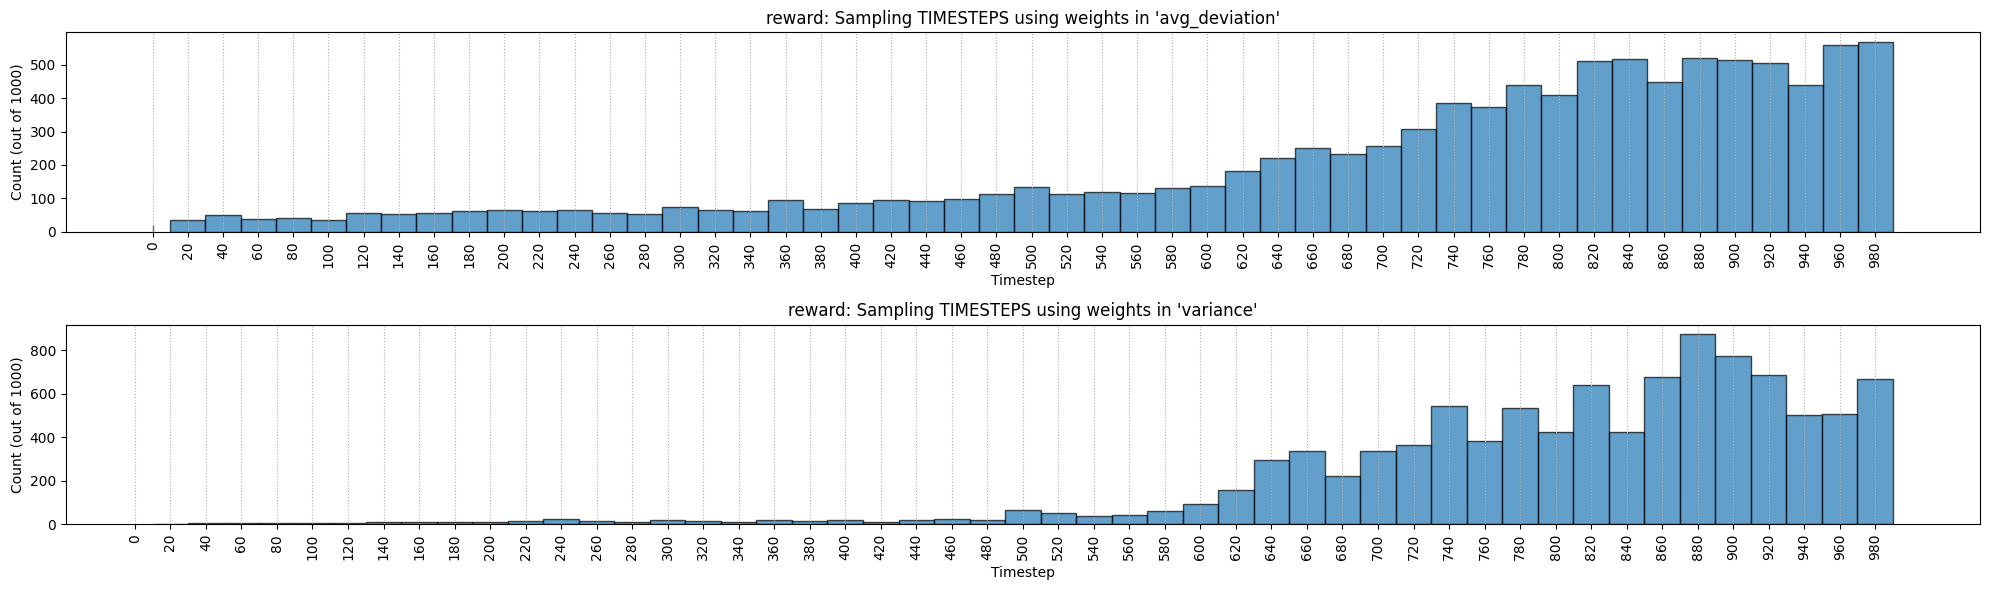

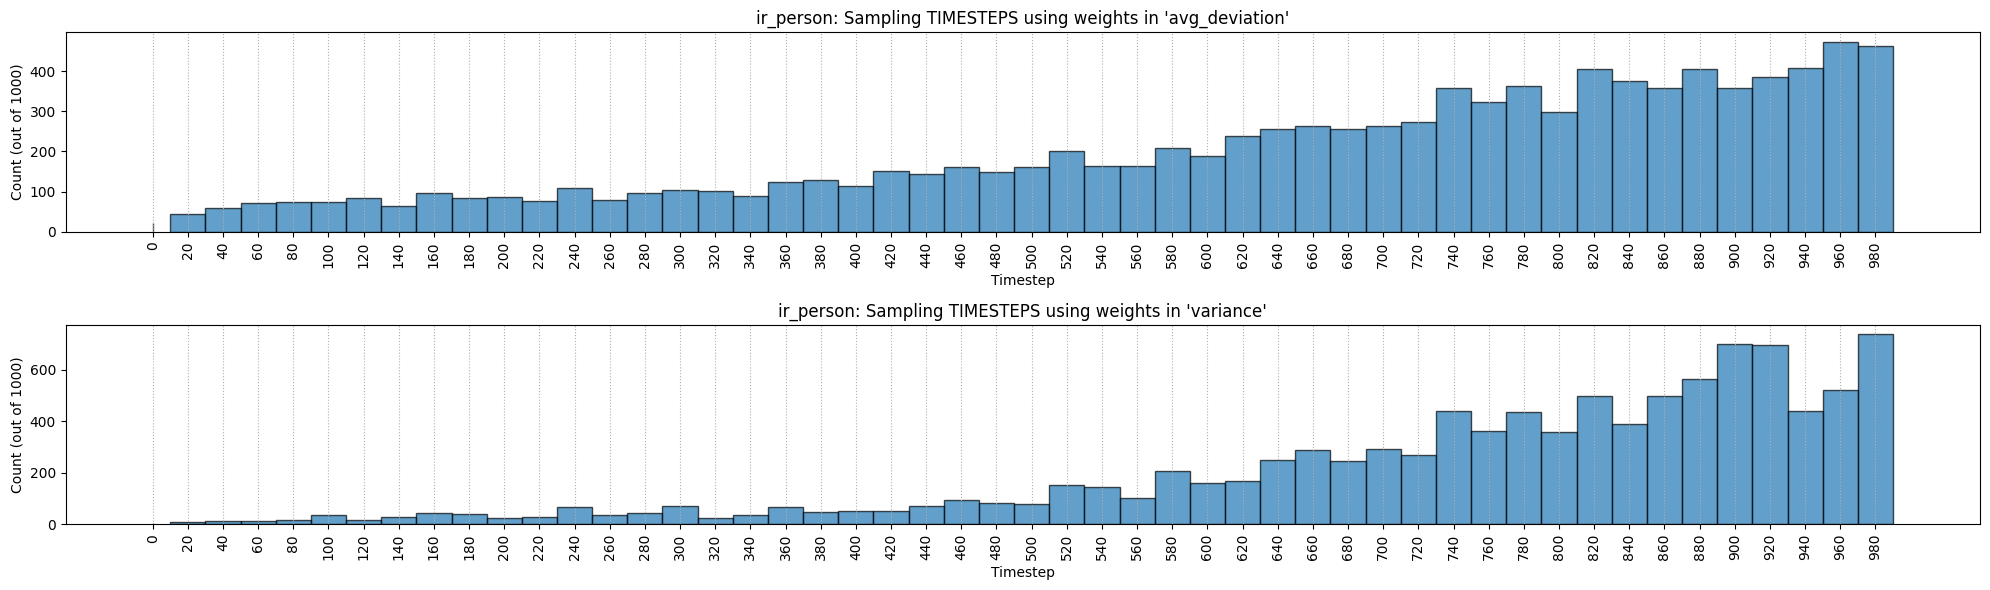

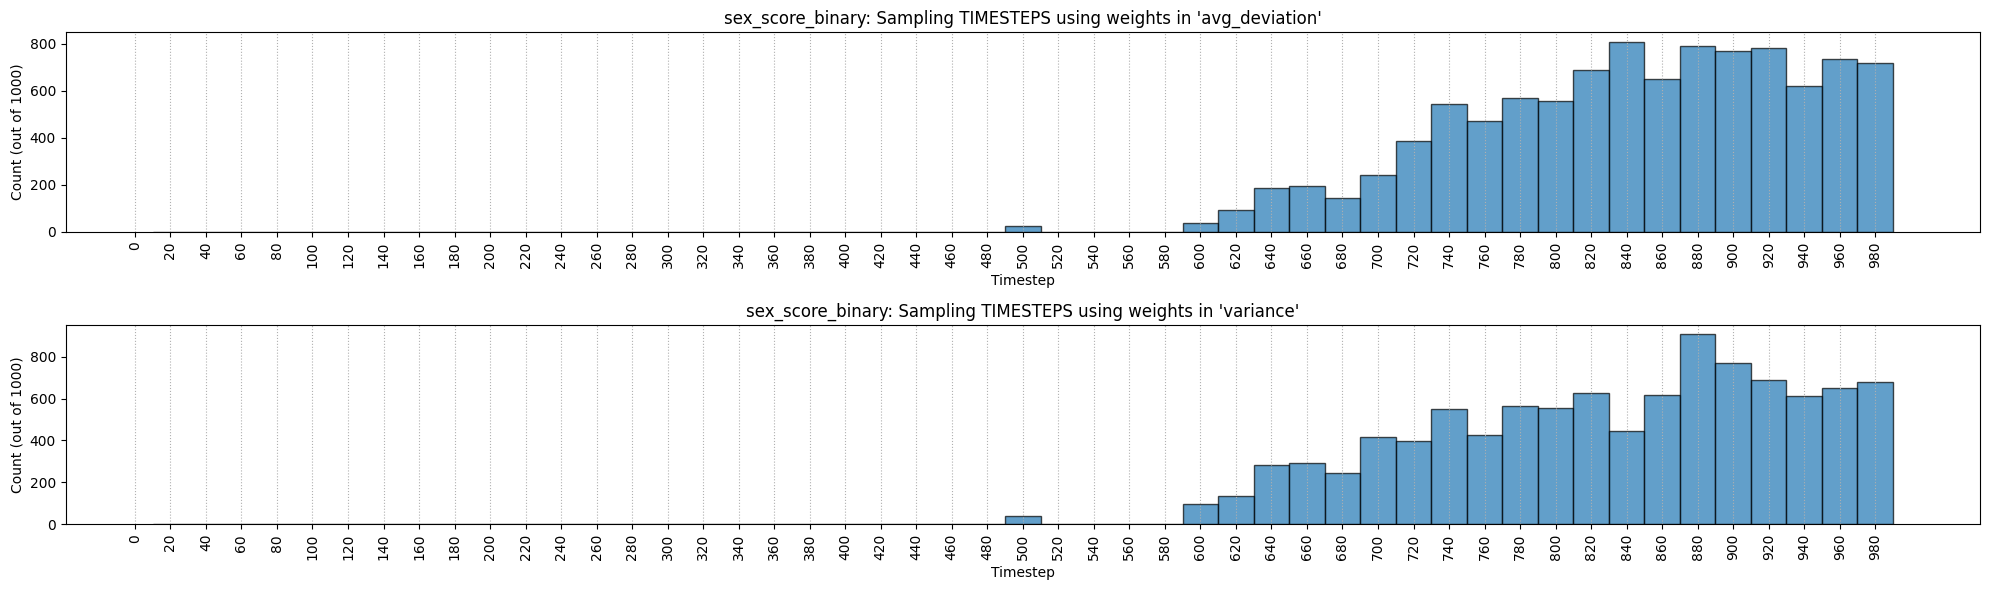

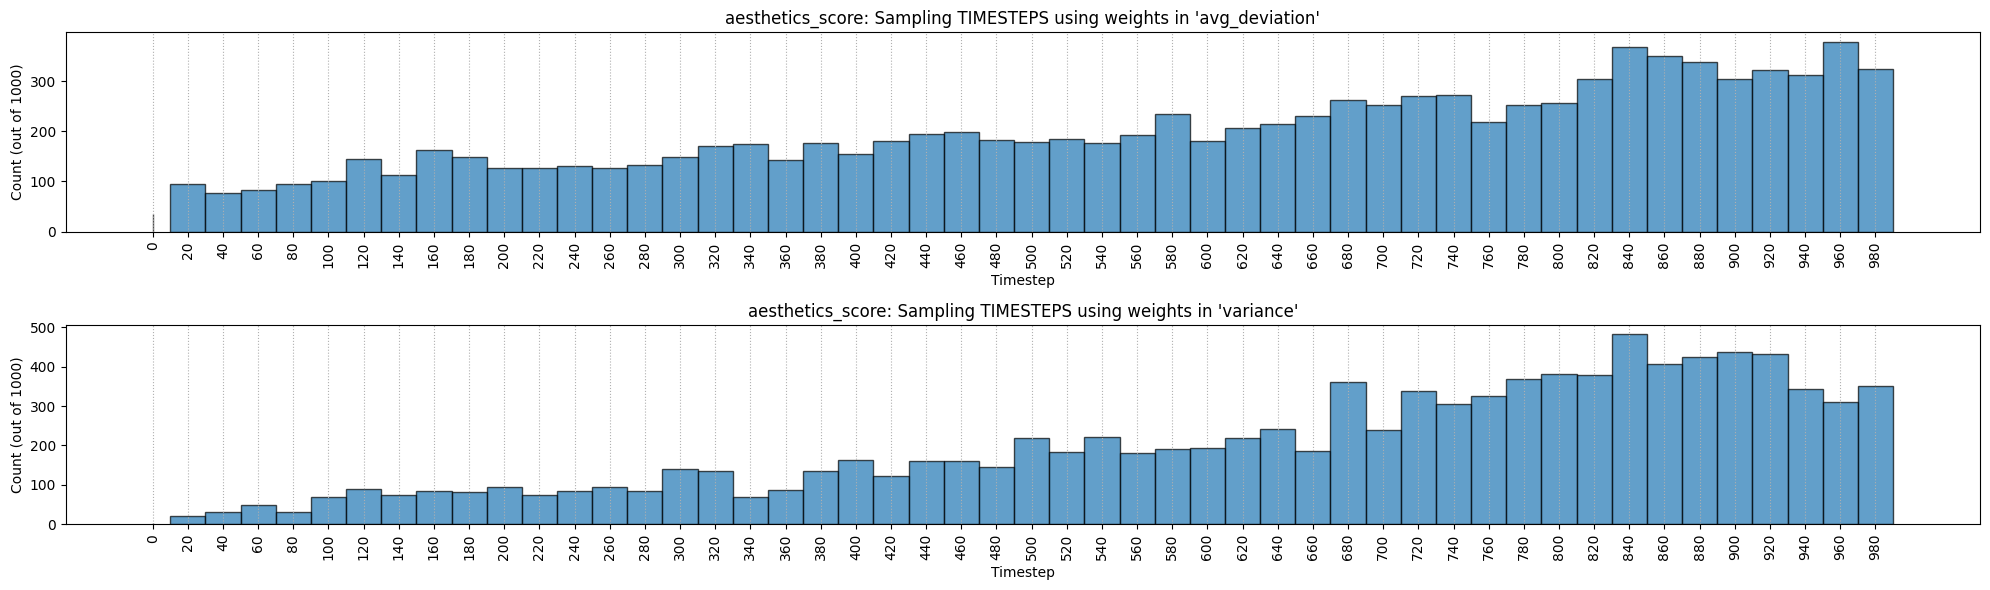

In [18]:
plot_empirical_sampling_distribution(df_metrics_subset, ['reward', 'ir_person', 'sex_score_binary', 'aesthetics_score'], ['avg_deviation', 'variance'])

### Compare subset vs all data

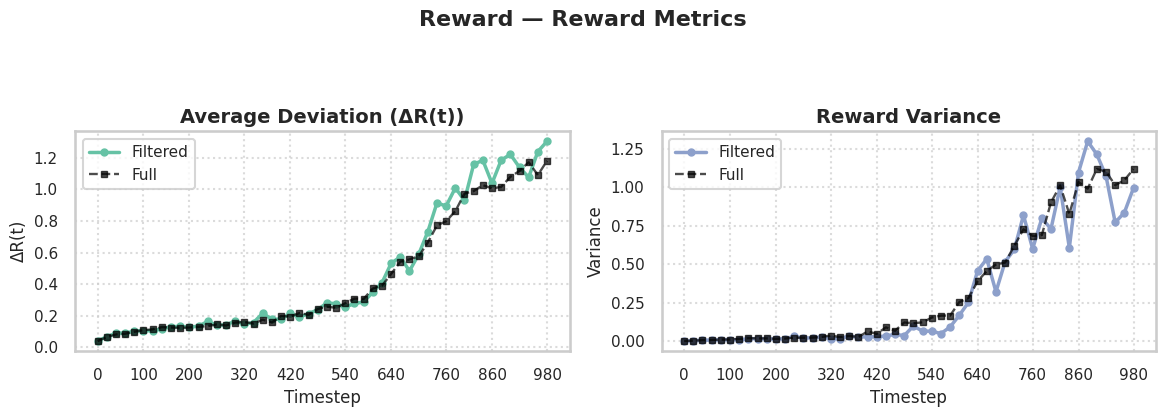

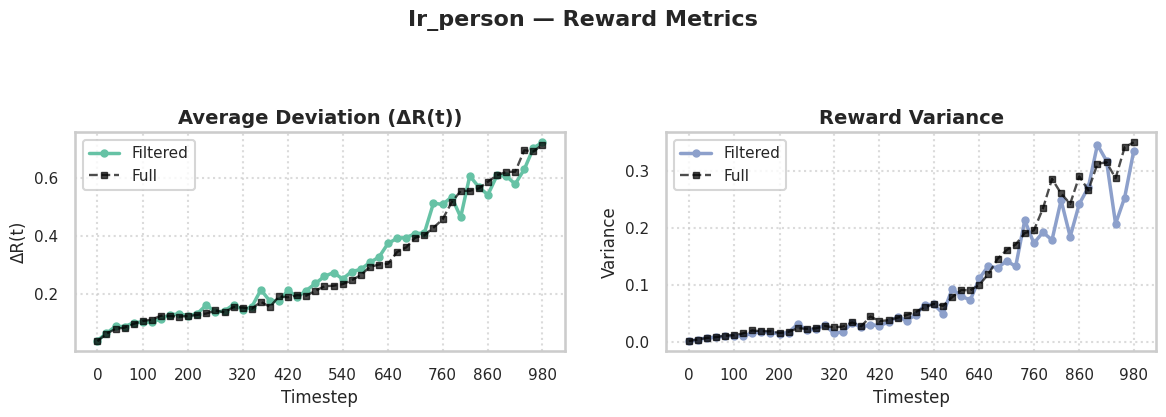

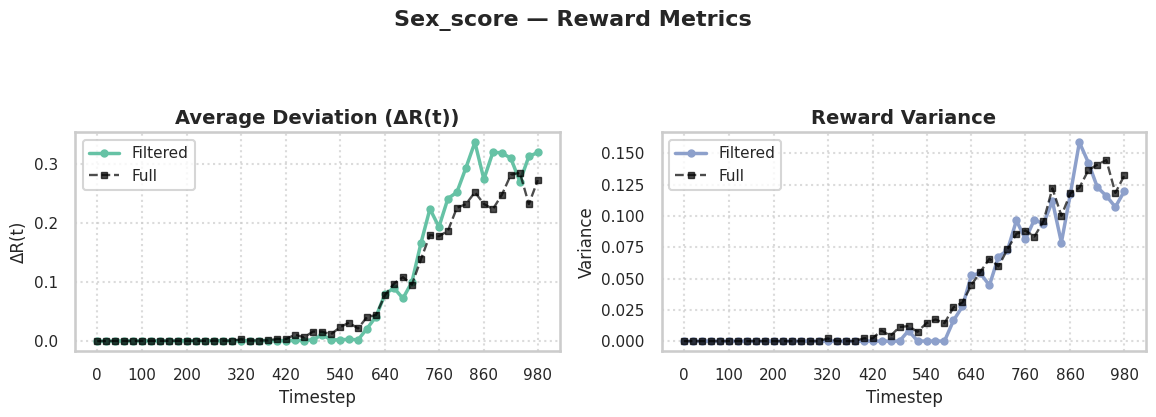

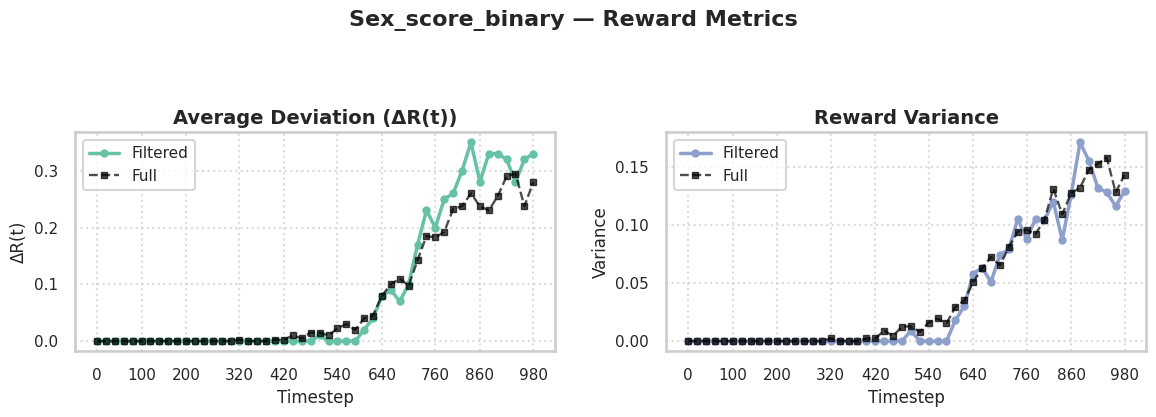

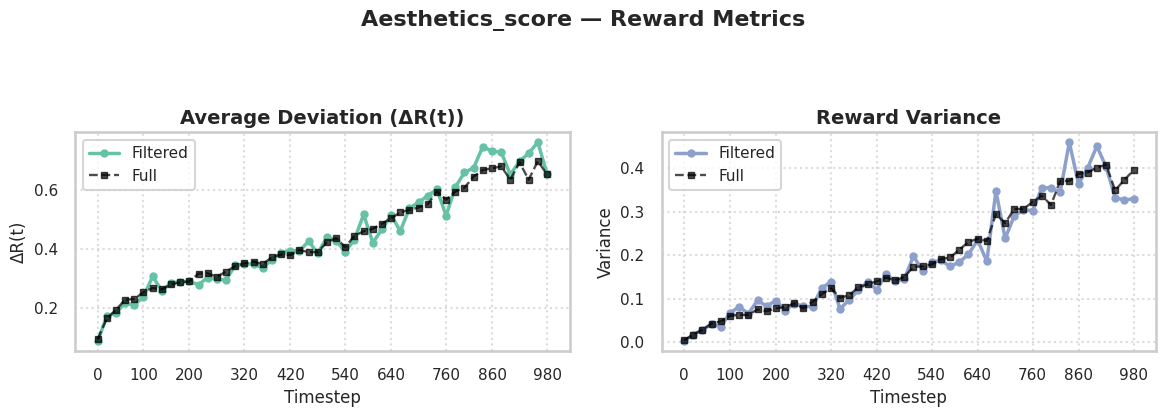

In [19]:
sns.set(style="whitegrid", context="talk")

for reward in REWARDS:
    # Get the metric-specific DataFrame
    df_reward_subset = df_metrics_subset[df_metrics_subset["reward"] == reward]
    df_reward = df_metrics[df_metrics["reward"] == reward]

    # Extract values for filtered (df_reward_subset) and full (df_reward)
    delta_values = df_reward_subset["avg_deviation"].values
    variance_values = df_reward_subset["variance"].values
    timesteps = df_reward_subset["timestep"].values  
    
    timesteps_full = df_reward["timestep"].values
    delta_values_full = df_reward["avg_deviation"].values
    variance_values_full = df_reward["variance"].values

    colors = sns.color_palette("Set2", 3)

    # 1 row x 2 columns: avg_deviation and variance only
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False)

    # Plot filtered metrics
    axes[0].plot(timesteps, delta_values, marker="o", markersize=5, linewidth=2.5, color=colors[0], label="Filtered")
    # Plot full metrics
    axes[0].plot(timesteps_full, delta_values_full, marker="s", markersize=4, linewidth=1.7, linestyle='--', color="black", alpha=0.7, label="Full")

    axes[0].set_title("Average Deviation (ΔR(t))", fontsize=14, fontweight="semibold")
    axes[0].set_ylabel("ΔR(t)", fontsize=12)
    axes[0].set_xlabel("Timestep", fontsize=12)
    axes[0].grid(True, alpha=0.7, linestyle=":")
    axes[0].legend(fontsize=11)

    # Plot filtered metrics
    axes[1].plot(timesteps, variance_values, marker="o", markersize=5, linewidth=2.5, color=colors[2], label="Filtered")
    # Plot full metrics
    axes[1].plot(timesteps_full, variance_values_full, marker="s", markersize=4, linewidth=1.7, linestyle='--', color="black", alpha=0.7, label="Full")

    axes[1].set_title("Reward Variance", fontsize=14, fontweight="semibold")
    axes[1].set_ylabel("Variance", fontsize=12)
    axes[1].set_xlabel("Timestep", fontsize=12)
    axes[1].grid(True, alpha=0.7, linestyle=":")
    axes[1].legend(fontsize=11)

    # Shared x-axis formatting
    num_ticks = min(10, len(timesteps))
    if num_ticks > 1:
        tick_indices = np.linspace(0, len(timesteps) - 1, num_ticks, dtype=int)
        ticks_to_show = [timesteps[i] for i in tick_indices]
    else:
        ticks_to_show = timesteps

    for ax in axes:
        ax.tick_params(axis="both", labelsize=11)
        ax.set_xticks(ticks_to_show)
        ax.set_xticklabels(ticks_to_show, rotation=0)

    fig.suptitle(f"{reward.capitalize()} — Reward Metrics", fontsize=16, fontweight="bold", y=1.06)
    plt.tight_layout()
    plt.show()


### Plot metrics

Loading metrics from /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/avg_deviation_sex_score_binary.json
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/variance_sex_score_binary.json
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/avg_deviation_ir_person.json
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/variance_ir_person.json
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/avg_deviation_aesthetics_score.json
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/variance_aesthetics_score.json


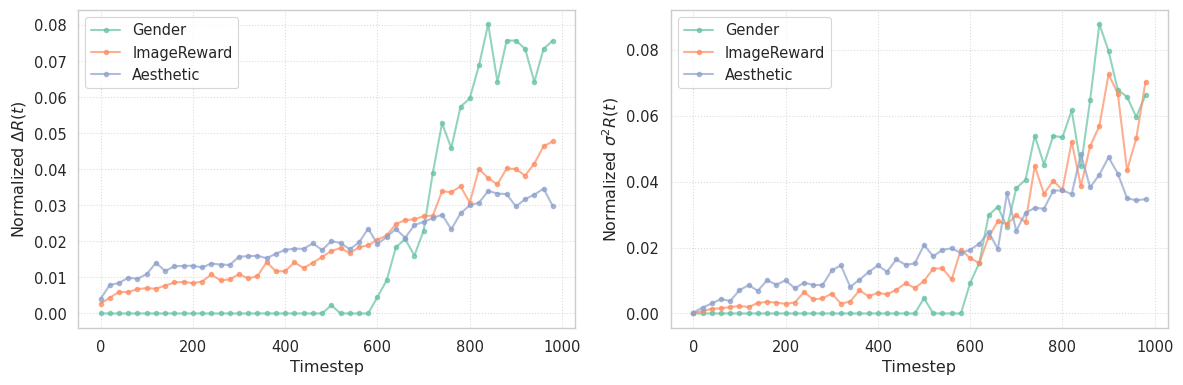

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

def plot_distributions_per_metric(
    rewards,
    metrics=None,
    base_path="/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward",
    df_metrics=None
):
    """
    Plot distribution (sum-to-1) for arbitrary metrics for multiple rewards.

    Args:
        rewards (list or dict): List of reward names or Dict mapping reward keys to display names.
        metrics (list or dict): List of metric names (str) or Dict mapping metric names to display labels.
        base_path (str): Base path where JSON metric files are stored.
        df_metrics (pd.DataFrame, optional): DataFrame for in-memory metrics [timestep, reward, ...metric cols...]
    """
    if not rewards or not metrics:
        raise ValueError("You must supply a list of rewards and metrics to plot.")

    if not isinstance(rewards, dict):
        rewards = {reward: reward for reward in rewards}
    if not isinstance(metrics, dict):
        metrics = {metric: metric for metric in metrics}

    if df_metrics is None and base_path is None:
        raise ValueError("You must supply either a DataFrame or a base path for the JSON files.")

    if df_metrics is not None:
        print("Using DataFrame for metrics")
    else:
        print(f"Loading metrics from {base_path}")
        
    sns.set(style="whitegrid", font_scale=1.2, context="paper")

    n_metrics = len(metrics)
    fig, axes = plt.subplots(1, n_metrics, figsize=(6 * n_metrics, 4))
    if n_metrics == 1:
        axes = [axes]

    colors = sns.color_palette("Set2", n_colors=len(rewards))
    marker_style = "o"

    def make_distribution(x):
        x_sum = np.nansum(x)
        if x_sum == 0 or np.isnan(x_sum):
            return np.zeros_like(x)
        return x / x_sum

    for idx, (reward, label) in enumerate(rewards.items()):
        metric_data = {}
        timestep_set = set()

        if df_metrics is not None:
            df_r = df_metrics[df_metrics["reward"] == reward]
            for metric in metrics:
                vals = df_r[["timestep", metric]].dropna()
                metric_dict = dict(zip(vals["timestep"].astype(int), vals[metric]))
                metric_data[metric] = metric_dict
                timestep_set |= set(metric_dict.keys())
        else:
            for metric in metrics:
                metric_path = f"{base_path}/{metric}_{reward}.json"
                with open(metric_path, "r") as f:
                    print(f"Loading {metric_path}")
                    metric_dict = json.load(f)
                metric_data[metric] = {int(k): v for k, v in metric_dict.items()}
                timestep_set |= set(metric_data[metric].keys())

        timesteps = sorted(timestep_set)
        for m_idx, metric in enumerate(metrics):
            this_metric_dict = metric_data.get(metric, {})
            values = np.array([this_metric_dict.get(ts, np.nan) for ts in timesteps])
            dist_values = make_distribution(values)
            axes[m_idx].plot(
                timesteps,
                dist_values,
                label=label,
                color=colors[idx],
                linewidth=1.5,
                marker=marker_style,
                markersize=3,
                alpha=0.7,
            )

    for m_idx, metric in enumerate(metrics):
        #axes[m_idx].set_title(f"{metrics[metric]} Distribution", fontsize=13)
        axes[m_idx].set_xlabel("Timestep")
        axes[m_idx].set_ylabel(f"Normalized {metrics[metric]}")
        axes[m_idx].legend()
        axes[m_idx].grid(True, linestyle=":", alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_distributions_per_metric(
    rewards={"sex_score_binary": "Gender", "ir_person": "ImageReward", "aesthetics_score": "Aesthetic"}, 
    metrics={"avg_deviation": r"$\Delta R(t)$", "variance": r"$\sigma^2 R(t)$"}
)


Using DataFrame for metrics


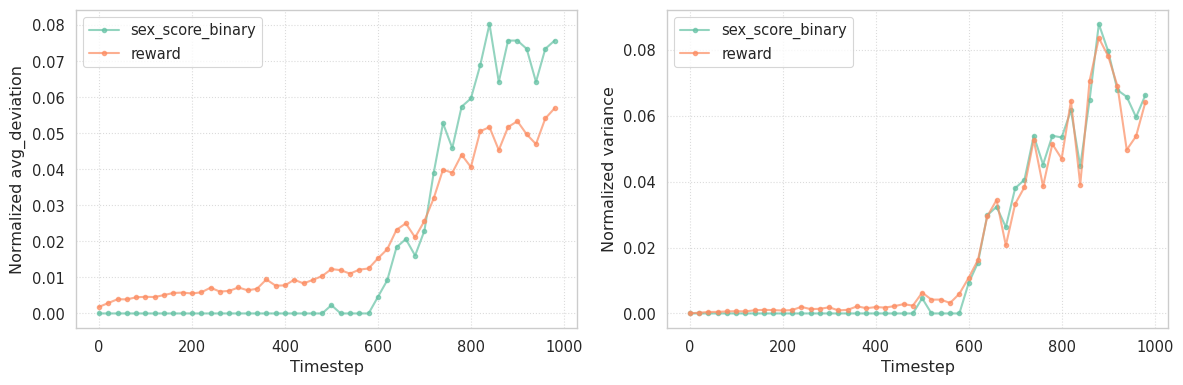

In [47]:
plot_distributions_per_metric(
    rewards=["sex_score_binary", "reward"], 
    metrics=["avg_deviation", "variance"],
    df_metrics=df_metrics_subset
)

Loading metrics from /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/avg_deviation_reward.json
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/variance_reward.json
Loading /home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward/snr_weight_reward.json


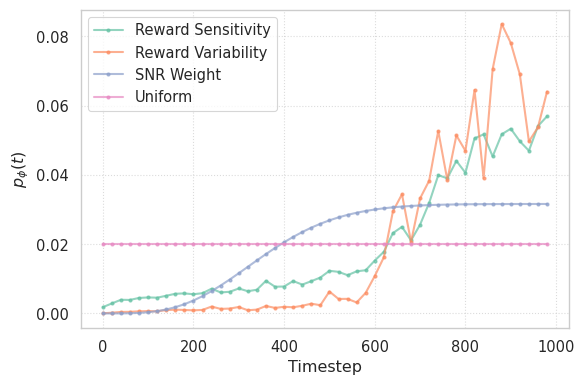

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

def plot_distributions_per_reward(
    rewards,
    metrics=None,
    base_path="/home/amanda_mendes_cloudwalk_io/Fine-Tuning-Diffusion-Models-With-RL/p2_reward",
    df_metrics=None,
    add_uniform=False
):
    """
    Plot distribution (sum-to-1) for arbitrary metrics for each reward.
    Each subplot corresponds to a reward (not a metric).

    Args:
        rewards (list or dict): List of reward names or Dict mapping reward keys to display names.
        metrics (list or dict): List of metric names (str) or Dict mapping metric names to display labels.
        base_path (str): Base path where JSON metric files are stored.
        df_metrics (pd.DataFrame, optional): DataFrame for in-memory metrics [timestep, reward, ...metric cols...]
        add_uniform (bool): Whether to plot a uniform distribution for reference. Default: False.
    """
    if not rewards or not metrics:
        raise ValueError("You must supply a list of rewards and metrics to plot.")

    if not isinstance(rewards, dict):
        rewards = {reward: reward for reward in rewards}
    if not isinstance(metrics, dict):
        metrics = {metric: metric for metric in metrics}

    if df_metrics is None and base_path is None:
        raise ValueError("You must supply either a DataFrame or a base path for the JSON files.")

    if df_metrics is not None:
        print("Using DataFrame for metrics")
    else:
        print(f"Loading metrics from {base_path}")

    sns.set(style="whitegrid", font_scale=1.2, context="paper")

    n_rewards = len(rewards)
    fig, axes = plt.subplots(1, n_rewards, figsize=(6 * n_rewards, 4))
    if n_rewards == 1:
        axes = [axes]

    colors = sns.color_palette("Set2", n_colors=len(metrics)+1 if add_uniform else len(metrics))
    marker_style = "o"

    def make_distribution(x):
        x_sum = np.nansum(x)
        if x_sum == 0 or np.isnan(x_sum):
            return np.zeros_like(x)
        return x / x_sum

    for idx, (reward, label) in enumerate(rewards.items()):
        metric_data = {}
        timestep_set = set()

        if df_metrics is not None:
            df_r = df_metrics[df_metrics["reward"] == reward]
            for metric in metrics:
                vals = df_r[["timestep", metric]].dropna()
                metric_dict = dict(zip(vals["timestep"].astype(int), vals[metric]))
                metric_data[metric] = metric_dict
                timestep_set |= set(metric_dict.keys())
        else:
            for metric in metrics:
                metric_path = f"{base_path}/{metric}_{reward}.json"
                with open(metric_path, "r") as f:
                    print(f"Loading {metric_path}")
                    metric_dict = json.load(f)
                metric_data[metric] = {int(k): v for k, v in metric_dict.items()}
                timestep_set |= set(metric_data[metric].keys())

        timesteps = sorted(timestep_set)
        ax = axes[idx]
        for m_idx, metric in enumerate(metrics):
            this_metric_dict = metric_data.get(metric, {})
            values = np.array([this_metric_dict.get(ts, np.nan) for ts in timesteps])
            dist_values = make_distribution(values)
            ax.plot(
                timesteps,
                dist_values,
                label=metrics[metric],
                color=colors[m_idx],
                linewidth=1.5,
                marker=marker_style,
                markersize=2,
                alpha=0.7,
            )

        # Plot uniform distribution if requested
        if add_uniform and len(timesteps) > 0:
            uniform_dist = np.full_like(timesteps, 1.0 / len(timesteps), dtype=float)
            ax.plot(
                timesteps,
                uniform_dist,
                label="Uniform",
                color=colors[-1],
                marker=marker_style,
                linewidth=1.5,
                markersize=2,
                alpha=0.7,
            )

        #ax.set_title(f"{label}", fontsize=13)
        ax.set_xlabel("Timestep")
        ax.set_ylabel(r"$p_\phi(t)$")
        ax.legend()
        ax.grid(True, linestyle=":", alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_distributions_per_reward(
    rewards={"reward": "Total Reward"}, 
    metrics={"avg_deviation": "Reward Sensitivity", "variance": "Reward Variability", "snr_weight": "SNR Weight"},
    add_uniform=True  # Enable plotting the uniform distribution
)


# Generate GIFS

In [ ]:
import os
from PIL import Image, ImageDraw, ImageFont

def make_reconstruction_gif(worker_id, image_id, plot_dir, timesteps, num_samples=5, gif_path=None):
    """
    Creates a GIF showing reconstructed images across timesteps for a given worker and image,
    with timestep labeled on each frame.

    Args:
        worker_id (int): Worker folder ID (e.g., 0, 1)
        image_id (int): Image index
        plot_dir (str): Base directory where worker folders are stored
        timesteps (list[int]): List of timesteps to include
        num_samples (int): Number of denoised samples per timestep to include in the grid
        gif_path (str): Optional path to save the GIF. If None, will save to plot_dir.
    """
    worker_folder = os.path.join(plot_dir, f"worker_{worker_id}", "recon_plots")
    frames = []
    text_height = 15  # smaller space for timestep label

    for t in timesteps:
        # Collect denoised sample images for this timestep and image
        imgs = []
        for sample_idx in range(num_samples):
            img_path = os.path.join(worker_folder, f"img{image_id}_t{t}_sample{sample_idx}.png")
            if os.path.exists(img_path):
                imgs.append(Image.open(img_path))
        
        if not imgs:
            continue  # Skip if no images found

        # Create horizontal grid
        widths, heights = zip(*(i.size for i in imgs))
        total_width = sum(widths)
        max_height = max(heights)
        grid_img = Image.new('RGB', (total_width, max_height + text_height), color=(255, 255, 255))
        x_offset = 0
        for im in imgs:
            grid_img.paste(im, (x_offset, text_height))  # leave space for text at top
            x_offset += im.width

        # Draw timestep text
        draw = ImageDraw.Draw(grid_img)
        try:
            font = ImageFont.truetype("arial.ttf", 14)
        except:
            font = ImageFont.load_default()
        draw.text((5, 0), f"Timestep: {t}", fill=(0, 0, 0), font=font)

        frames.append(grid_img)

    if not frames:
        print(f"No frames found for worker {worker_id} image {image_id}")
        return None

    if gif_path is None:
        gif_path = os.path.join(plot_dir, f"worker_{worker_id}", f"image_{image_id}_recon.gif")

    frames[0].save(
        gif_path, format='GIF',
        append_images=frames[1:], save_all=True,
        duration=500, loop=0
    )
    print(f"GIF saved to {gif_path}")
    return gif_path


In [13]:
# n_workers = len(csv_files)
# images_per_worker = all_data['image_idx'].nunique() // len(csv_files)
# print(f"Found {n_workers} workers and {images_per_worker} images per worker")
# for worker_id in range(len(csv_files)):
#     for image_id in range(images_per_worker):
#         make_reconstruction_gif(worker_id=worker_id, image_id=image_id, plot_dir=BASE_DIR, timesteps=timesteps, num_samples=20)

# Generate image grid

In [66]:
import os
import re
import pandas as pd

def extract_indices_from_filename(filename):
    # Example filename: img_4_t20_sample15.png
    match = re.match(r'img(\d+)_t(\d+)_sample(\d+)\.png', filename)
    if match:
        image_idx, timestep, sample_idx = match.groups()
        return int(image_idx), int(timestep), int(sample_idx)
    return None

def collect_all_files(base_dir):
    records = []
    for worker in os.listdir(base_dir):
        worker_dir = os.path.join(base_dir, worker)
        if not (os.path.isdir(worker_dir) and worker.startswith('worker_')):
            continue
        for subfolder in ['original_images', 'recon_plots']:
            img_dir = os.path.join(worker_dir, subfolder)
            if not os.path.isdir(img_dir):
                continue
            for fname in os.listdir(img_dir):
                indices = extract_indices_from_filename(fname)
                if indices is not None:
                    image_idx, timestep, sample_idx = indices
                    fpath = os.path.join(img_dir, fname)

                    records.append({
                        'worker': worker,
                        'filepath': fpath,
                        'image': image_idx,
                        'timestep': timestep,
                        'sample': sample_idx,
                        'type': subfolder  # indicate whether original or recon
                    })
    df = pd.DataFrame(records)
    return df


all_imgs_df = collect_all_files(BASE_DIR)
all_imgs_df.head()


,worker,filepath,image,timestep,sample,type
0,worker_0,../p2_reward/worker_0/recon_plots/img4_t740_sa...,4,740,14,recon_plots
1,worker_0,../p2_reward/worker_0/recon_plots/img2_t100_sa...,2,100,8,recon_plots
2,worker_0,../p2_reward/worker_0/recon_plots/img2_t40_sam...,2,40,14,recon_plots
3,worker_0,../p2_reward/worker_0/recon_plots/img4_t900_sa...,4,900,6,recon_plots
4,worker_0,../p2_reward/worker_0/recon_plots/img0_t860_sa...,0,860,11,recon_plots


In [ ]:
# Extract worker number from worker column
all_imgs_df = all_imgs_df.copy()
all_imgs_df['worker_num'] = all_imgs_df['worker'].str.extract(r'worker_(\d+)').astype(int)
all_imgs_df['global_image_id'] = all_imgs_df['worker_num'] * 5 + all_imgs_df['image']



,worker,filepath,image,timestep,sample,type,worker_num,global_image_id
0,worker_0,../p2_reward/worker_0/recon_plots/img4_t740_sa...,4,740,14,recon_plots,0,4
1,worker_0,../p2_reward/worker_0/recon_plots/img2_t100_sa...,2,100,8,recon_plots,0,2
2,worker_0,../p2_reward/worker_0/recon_plots/img2_t40_sam...,2,40,14,recon_plots,0,2
3,worker_0,../p2_reward/worker_0/recon_plots/img4_t900_sa...,4,900,6,recon_plots,0,4
4,worker_0,../p2_reward/worker_0/recon_plots/img0_t860_sa...,0,860,11,recon_plots,0,0
...,...,...,...,...,...,...,...,...
19995,worker_3,../p2_reward/worker_3/recon_plots/img0_t700_sa...,0,700,15,recon_plots,3,15
19996,worker_3,../p2_reward/worker_3/recon_plots/img3_t400_sa...,3,400,4,recon_plots,3,18
19997,worker_3,../p2_reward/worker_3/recon_plots/img3_t360_sa...,3,360,13,recon_plots,3,18
19998,worker_3,../p2_reward/worker_3/recon_plots/img1_t240_sa...,1,240,18,recon_plots,3,16


In [88]:
n_imgs = 10  
n_recons = 3  
n_timesteps = 4

selected_image_idxs = image_idx_samples[:n_imgs]
selected_sample_idxs = sample_idx_samples[:n_recons]
timesteps_all = sorted(all_imgs_df['timestep'].unique())
timesteps = [timesteps_all[i] for i in np.linspace(0, len(timesteps_all)-1, n_timesteps, dtype=int)]

filtered_imgs_df = all_imgs_df[
    all_imgs_df['global_image_id'].isin(selected_image_idxs) &
    all_imgs_df['sample'].isin(selected_sample_idxs) &
    all_imgs_df['timestep'].isin(timesteps)
]

filtered_imgs_df

,worker,filepath,image,timestep,sample,type,worker_num,global_image_id
117,worker_0,../p2_reward/worker_0/recon_plots/img0_t320_sa...,0,320,19,recon_plots,0,0
517,worker_0,../p2_reward/worker_0/recon_plots/img3_t980_sa...,3,980,16,recon_plots,0,3
589,worker_0,../p2_reward/worker_0/recon_plots/img0_t980_sa...,0,980,15,recon_plots,0,0
746,worker_0,../p2_reward/worker_0/recon_plots/img0_t320_sa...,0,320,15,recon_plots,0,0
803,worker_0,../p2_reward/worker_0/recon_plots/img1_t320_sa...,1,320,19,recon_plots,0,1
...,...,...,...,...,...,...,...,...
19689,worker_3,../p2_reward/worker_3/recon_plots/img1_t640_sa...,1,640,16,recon_plots,3,16
19778,worker_3,../p2_reward/worker_3/recon_plots/img0_t980_sa...,0,980,16,recon_plots,3,15
19847,worker_3,../p2_reward/worker_3/recon_plots/img3_t980_sa...,3,980,15,recon_plots,3,18
19879,worker_3,../p2_reward/worker_3/recon_plots/img1_t0_samp...,1,0,19,recon_plots,3,16


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def plot_reconstructions_from_df(
        all_imgs_df,
        selected_image_idxs,
        selected_sample_idxs,
        timesteps,
        max_width_per_img=2,
        max_height_per_img=2,
        cmap='gray'
    ):
    """
    For each global image id in selected_image_idxs, plot all reconstructions from selected_sample_idxs
    and timesteps. 1 column per timestep, 1 row per reconstruction. Absolutely no space between images.
    """
    filtered_imgs_df = all_imgs_df[
        all_imgs_df['global_image_id'].isin(selected_image_idxs) &
        all_imgs_df['sample'].isin(selected_sample_idxs) &
        all_imgs_df['timestep'].isin(timesteps)
    ].copy()

    for img_id in selected_image_idxs:
        img_df = filtered_imgs_df[filtered_imgs_df['global_image_id'] == img_id]
        fig, axes = plt.subplots(
            len(selected_sample_idxs), len(timesteps),
            figsize=(max_width_per_img * len(timesteps), max_height_per_img * len(selected_sample_idxs)),
            gridspec_kw={'left': 0, 'right': 1, 'top': 1, 'bottom': 0, 'wspace': 0.0, 'hspace': 0.0}
        )

        # Make axes 2D for consistent indexing
        if len(selected_sample_idxs) == 1:
            axes = axes[None, :]
        if len(timesteps) == 1:
            axes = axes[:, None]
        for row, sample_idx in enumerate(selected_sample_idxs):
            for col, t in enumerate(timesteps):
                subdf = img_df[(img_df['sample'] == sample_idx) & (img_df['timestep'] == t)]
                ax = axes[row, col]
                if not subdf.empty:
                    img_path = subdf['filepath'].values[0]
                    img = Image.open(img_path)
                    ax.imshow(img, cmap=cmap)
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_frame_on(False)
                # Remove all axis spines aggressively just in case
                for k in ax.spines:
                    ax.spines[k].set_visible(False)
                if row == 0:
                    ax.set_title(f"Timestep {t}", pad=2)
        fig.suptitle(f"Global Image {img_id}", y=1.02)
        plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0, wspace=0.0, hspace=0.0)
        plt.margins(0,0)
        plt.show()

# Example usage:
plot_reconstructions_from_df(
    all_imgs_df=all_imgs_df,
    selected_image_idxs=image_idx_samples[:10],
    selected_sample_idxs=sample_idx_samples[:3],
    timesteps=[sorted(all_imgs_df['timestep'].unique())[i] for i in np.linspace(0, len(all_imgs_df['timestep'].unique())-1, 10, dtype=int)]
)

# Archive

### Check distribution of rewards per image

In [ ]:
def plot_reward_histograms_with_original(df, ranges=None, timesteps=None, metric_col="reward", num_bins=10, value_min=None, value_max=None, image_idxs=None):
    """
    Plot histograms of rewards per image at each timestep with the original reward marked.

    This function will derive bin edges from `value_min`/`value_max` if provided,
    or try to use the `ranges` dictionary (if defined in the notebook). If neither is
    available it falls back to the column min/max in `df`.

    Args:
        df: DataFrame containing the samples
        timesteps: list of timesteps to plot (defaults to sorted unique timesteps)
        metric_col: column name to plot
        num_bins: number of histogram bins (default: 10)
        value_min: optional minimum value for bins (inclusive)
        value_max: optional maximum value for bins (inclusive)
        image_idxs: optional list of image indices to include
    """
    sns.set(style="whitegrid", context="talk")

    if timesteps is None:
        timesteps = sorted(df["timestep"].dropna().unique().astype(int))

    # Determine value_min / value_max from arguments, RANGES (if present), or data
    if value_min is None or value_max is None:
        try:
            rng = ranges.get(metric_col, None)  
        except NameError:
            rng = None
        if rng is not None and value_min is None and value_max is None:
            value_min, value_max = float(rng[0]), float(rng[1])
        else:
            # Fall back to data-driven range
            col = df[metric_col].dropna()
            value_min = float(col.min()) if value_min is None else float(value_min)
            value_max = float(col.max()) if value_max is None else float(value_max)

    if value_max <= value_min:
        # Prevent degenerate bins; expand a tiny bit
        value_max = value_min + 1e-6

    # Create bin edges
    bin_edges = np.linspace(value_min, value_max, num_bins + 1)

    # Map image_idx -> original reward
    orig_metrics = df[df["sample_idx"].isnull()].set_index("image_idx")[metric_col].to_dict()

    palette = sns.color_palette("Blues", n_colors=5)

    for t in timesteps:
        t_df = df[(df["sample_idx"].notnull()) & (df["timestep"] == t)]
        images = sorted(t_df["image_idx"].unique())

        if image_idxs is not None:
            images = [img for img in images if img in image_idxs]

        if not images:
            continue

        num_images = len(images)
        fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 4), squeeze=False)

        for i, img_idx in enumerate(images):
            samples = t_df[t_df["image_idx"] == img_idx][metric_col].values
            ax = axes[0, i]

            # Use the precomputed bin edges and set x-limits to the provided range
            if samples.size > 0:
                ax.hist(samples, bins=bin_edges, color=palette[3], edgecolor="black", alpha=0.8, density=True)
            else:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)

            orig_value = orig_metrics.get(img_idx, None)
            if orig_value is not None:
                ax.axvline(orig_value, color="crimson", linestyle="--", linewidth=2, label="Original reward")

            ax.set_title(f"Image {img_idx}", fontsize=14, fontweight="semibold")
            ax.set_xlabel(metric_col.capitalize(), fontsize=12)
            ax.set_ylabel("Density", fontsize=12)
            ax.set_xlim(value_min, value_max)
            ax.legend(frameon=True)
            ax.grid(alpha=0.3, linestyle=":")

        plt.suptitle(f"Timestep {t}: Distribution of {metric_col} per image", fontsize=16, fontweight="bold", y=1.05)
        plt.tight_layout()
        plt.show()

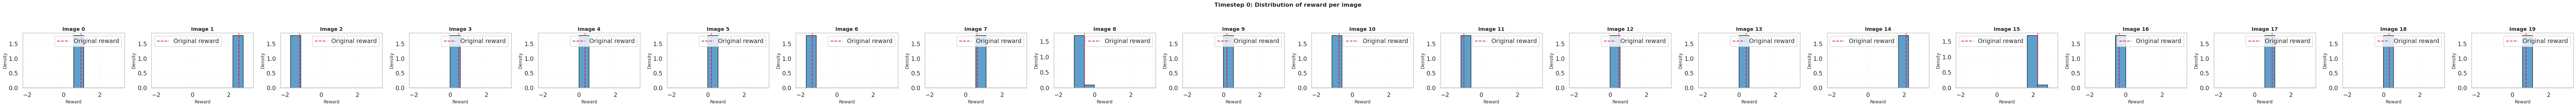

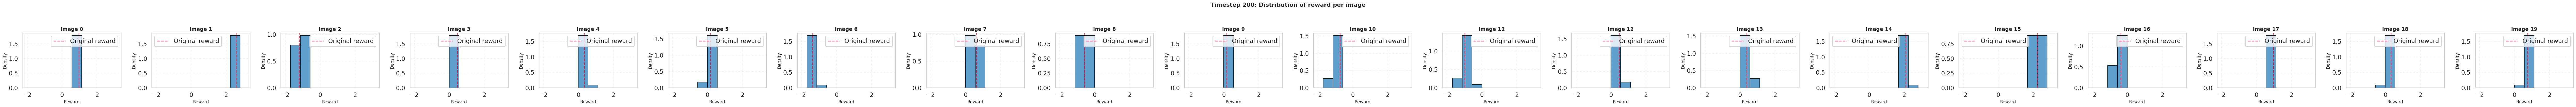

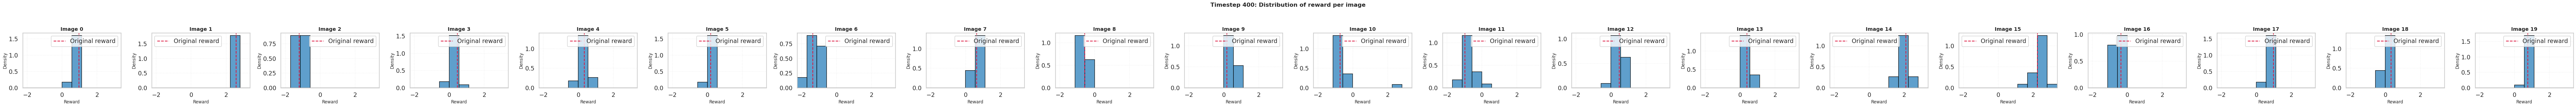

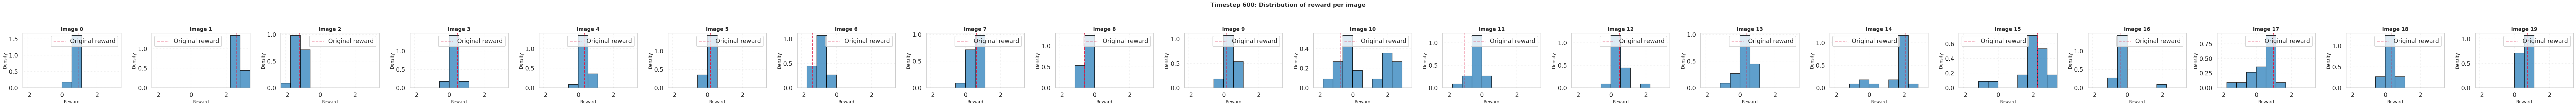

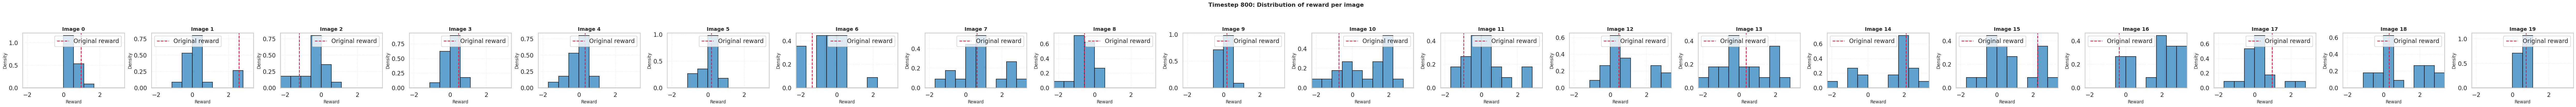

In [ ]:
plot_reward_histograms_with_original(all_data, ranges=RANGES, timesteps=list(range(0, 1000, 200)), metric_col="reward", num_bins=10, value_min=None, value_max=None, image_idxs=None)

### Sampling without replacement

In [ ]:
# Repeat multinomial sampling 50 times, each time sampling 20 timesteps without replacement,
# accumulate counts to show which timesteps are sampled most frequently.

metric = "reward"
df_metric = df_metrics[df_metrics["metric"] == metric]
timesteps = df_metric["timestep"].values
grad_vals = df_metric["d_avg_deviation_grad"].values

# Convert to float and handle nan/inf, then abs
grad_vals = pd.to_numeric(grad_vals, errors='coerce').astype(float)
grad_vals = np.nan_to_num(grad_vals, nan=0.0, posinf=0.0, neginf=0.0)
weights = np.abs(grad_vals)
weights_tensor = torch.tensor(weights, dtype=torch.float)

n_sample = min(20, (weights > 0).sum())  # Only sample as many nonzero as possible

# Prepare to collect overall counts for each timestep
timestep_counts = np.zeros_like(timesteps, dtype=int)
has_enough = torch.any(weights_tensor > 0) and (weights > 0).sum() >= 20

if has_enough:
    for i in range(50):
        sample_indices = torch.multinomial(weights_tensor, num_samples=20, replacement=False).numpy()
        sampled_timesteps = timesteps[sample_indices]
        # Count for each sampled timestep
        unique_timesteps, counts = np.unique(sampled_timesteps, return_counts=True)
        count_dict = dict(zip(unique_timesteps, counts))
        timestep_counts += np.array([count_dict.get(t, 0) for t in timesteps])
else:
    sampled_timesteps = []

# Make a histogram (bar of counts per timestep) over all 50 x 20 samples
plt.figure(figsize=(10, 3))
if not has_enough:
    plt.text(0.5, 0.5, "Not enough nonzero weights", fontsize=15, ha='center')
else:
    plt.bar(timesteps, timestep_counts, width=np.diff(timesteps, prepend=timesteps[0]),
            color="orange", edgecolor="black", alpha=0.7)
    plt.xlabel("Timestep")
    plt.ylabel("Sample Count (out of 1000)")
    plt.title("Multinomial Sampling 50x (20 w/o repl): abs(d_avg_deviation_grad) weights")
    plt.xticks(timesteps, rotation=90 if len(timesteps) > 15 else 0)
plt.grid(axis="x", linestyle=":")
plt.show()
